**PART 01 IMPORT LIBRARIES**

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import joblib

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from xgboost import (
    XGBRegressor,
    XGBClassifier
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

**PART 02 LOAD DATASET**

In [8]:
df = pd.read_csv("engineered_accessibility_dataset.csv")

**PART 03 ENCODE CLASSIFICATION TARGET**

In [9]:
encoder = LabelEncoder()

df["Accessibility_Category"] = encoder.fit_transform(
    df["Accessibility_Category"]
)

**PART 04 PREPARE FEATURES**

In [10]:
X_reg = df.drop(columns=[
    "Accessibility_Score",
    "Accessibility_Category",
    "Improvement_Priority",
    "Accessibility_Efficiency",
    "Location_ID",
    "Location_Name"
], errors="ignore")

y_reg = df["Accessibility_Score"]

# Classification
X_cls = X_reg.copy()
y_cls = df["Accessibility_Category"]

**PART 05 SCALE FEATURES**

In [11]:
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)
X_cls_scaled = scaler.transform(X_cls)

**STEP 06 TRAIN/TEST SPLIT**

In [12]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.20,
    random_state=42
)

#Classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_scaled,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

# **SECTION 02 HYPERPARAMETER TUNING (REGRESSION)**

**STEP 01 RANDOM FOREST HYPERPARAMETER TUNING**

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_reg, y_train_reg)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2', verbose=1)

**STEP 02 BEST PARAMETERS**

In [14]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV R²:")
print(round(rf_search.best_score_, 3))

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best CV R²:
0.822


**STEP 03 EVALUATE BEST RANDOM FOREST**

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_rf = rf_search.best_estimator_

prediction = best_rf.predict(X_test_reg)

print("MAE :", round(mean_absolute_error(y_test_reg, prediction), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test_reg, prediction)), 3))
print("R² :", round(r2_score(y_test_reg, prediction), 3))

MAE : 7.521
RMSE : 9.223
R² : 0.86


**STEP 04 XGBOSST GYPERPARAMETER TUNING**

In [16]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_reg, y_train_reg)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

**STEP 05 BEST PARAMETERS**

In [17]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV R²:")
print(round(xgb_search.best_score_, 3))

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV R²:
0.962


**STEP 06 EVALUATE THE XGBOOST**

In [18]:
best_xgb = xgb_search.best_estimator_

prediction = best_xgb.predict(X_test_reg)

print("MAE :", round(mean_absolute_error(y_test_reg, prediction), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test_reg, prediction)), 3))
print("R² :", round(r2_score(y_test_reg, prediction), 3))

MAE : 2.819
RMSE : 3.489
R² : 0.98


**STEP 07 COMPARE BOTH OPTIMIZED MODELS**

In [19]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "R²": [
        r2_score(y_test_reg, best_rf.predict(X_test_reg)),
        r2_score(y_test_reg, best_xgb.predict(X_test_reg))
    ],
    "MAE": [
        mean_absolute_error(y_test_reg, best_rf.predict(X_test_reg)),
        mean_absolute_error(y_test_reg, best_xgb.predict(X_test_reg))
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, best_rf.predict(X_test_reg))),
        np.sqrt(mean_squared_error(y_test_reg, best_xgb.predict(X_test_reg)))
    ]
})

results = results.sort_values(by="R²", ascending=False)
results

,Model,R²,MAE,RMSE
1,XGBoost,0.979909,2.819179,3.488723
0,Random Forest,0.859582,7.521276,9.223094


**STEP 08 SAVE THE BEST MODEL**

In [20]:
import joblib
best_model = best_xgb if results.iloc[0]["Model"] == "XGBoost" else best_rf
joblib.dump(best_model, "best_regression_model.pkl")

['best_regression_model.pkl']

# **SECTION 02 HYPERPARAMETER TUNING (CLASSIFICATION)**

**STEP 01 RANDOM FOREST CLASSIFIER**

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_cls = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_cls,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_cls, y_train_cls)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy', verbose=1)

**STEP 02 BEST PARAMETERS**

In [22]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV Accuracy:")
print(round(rf_search.best_score_,3))

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Best CV Accuracy:
0.715


**STEP 03 EVALUATE BEST RANDOM FOREST**

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

best_rf_cls = rf_search.best_estimator_

prediction = best_rf_cls.predict(X_test_cls)

print("Accuracy :", round(accuracy_score(y_test_cls,prediction),3))
print("Precision :", round(precision_score(y_test_cls,prediction,average="weighted"),3))
print("Recall :", round(recall_score(y_test_cls,prediction,average="weighted"),3))
print("F1 :", round(f1_score(y_test_cls,prediction,average="weighted"),3))
print("Kappa :", round(cohen_kappa_score(y_test_cls,prediction),3))

print("\nClassification Report\n")
print(classification_report(y_test_cls,prediction))

Accuracy : 0.625
Precision : 0.583
Recall : 0.625
F1 : 0.593
Kappa : 0.447

Classification Report

              precision    recall  f1-score   support

           0       0.42      0.36      0.39        50
           1       0.70      0.81      0.75        32
           2       0.36      0.16      0.22        32
           3       0.72      0.88      0.79        86

    accuracy                           0.62       200
   macro avg       0.55      0.55      0.54       200
weighted avg       0.58      0.62      0.59       200



**STEP 04 CONFUSION MATRIX**

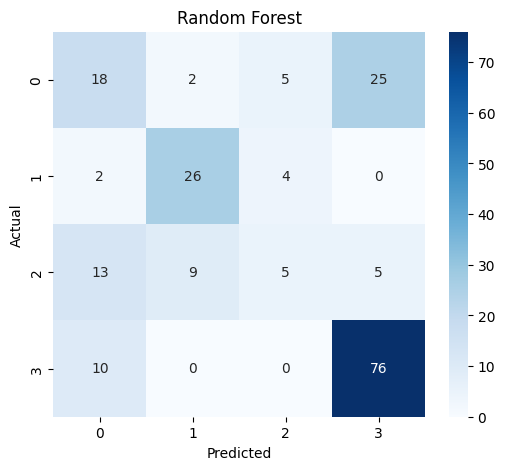

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls,prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest")

plt.show()

**STEP 05 XBGOOST CLASSIFIER**

In [25]:
from xgboost import XGBClassifier

xgb_cls = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_params = {
    "n_estimators":[100,200,300,500],
    "learning_rate":[0.01,0.05,0.1,0.2],
    "max_depth":[3,5,7,10],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_cls,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_cls,y_train_cls)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

**STEP 06 BEST PARAMETERS**

In [26]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV Accuracy:")
print(round(xgb_search.best_score_,3))

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Best CV Accuracy:
0.741


**STEP 07 EVALUATE THE XGBOOST**

In [27]:
best_xgb_cls = xgb_search.best_estimator_

prediction = best_xgb_cls.predict(X_test_cls)

print("Accuracy :", round(accuracy_score(y_test_cls,prediction),3))
print("Precision :", round(precision_score(y_test_cls,prediction,average="weighted"),3))
print("Recall :", round(recall_score(y_test_cls,prediction,average="weighted"),3))
print("F1 :", round(f1_score(y_test_cls,prediction,average="weighted"),3))
print("Kappa :", round(cohen_kappa_score(y_test_cls,prediction),3))

print("\nClassification Report\n")
print(classification_report(y_test_cls,prediction))

Accuracy : 0.67
Precision : 0.654
Recall : 0.67
F1 : 0.659
Kappa : 0.52

Classification Report

              precision    recall  f1-score   support

           0       0.51      0.54      0.52        50
           1       0.75      0.66      0.70        32
           2       0.33      0.25      0.29        32
           3       0.82      0.91      0.86        86

    accuracy                           0.67       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.65      0.67      0.66       200



**STEP 08 CONFUSUION MATRIX**

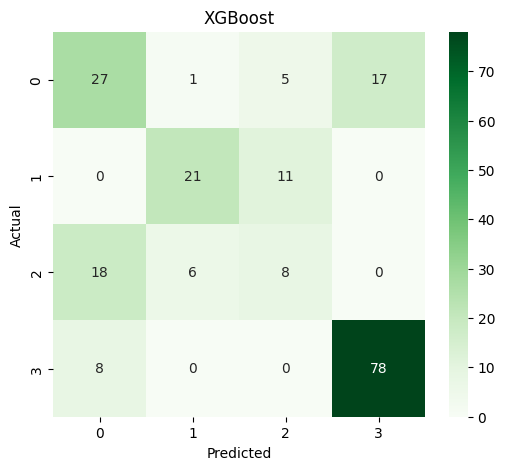

In [28]:
cm = confusion_matrix(y_test_cls,prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost")

plt.show()

**STEP 09 COMPARE BEST MODELS**

In [29]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(
            y_test_cls,
            best_rf_cls.predict(X_test_cls)
        ),
        accuracy_score(
            y_test_cls,
            best_xgb_cls.predict(X_test_cls)
        )
    ],

    "Precision":[
        precision_score(
            y_test_cls,
            best_rf_cls.predict(X_test_cls),
            average="weighted"
        ),
        precision_score(
            y_test_cls,
            best_xgb_cls.predict(X_test_cls),
            average="weighted"
        )
    ],

    "Recall":[
        recall_score(
            y_test_cls,
            best_rf_cls.predict(X_test_cls),
            average="weighted"
        ),
        recall_score(
            y_test_cls,
            best_xgb_cls.predict(X_test_cls),
            average="weighted"
        )
    ],

    "F1":[
        f1_score(
            y_test_cls,
            best_rf_cls.predict(X_test_cls),
            average="weighted"
        ),
        f1_score(
            y_test_cls,
            best_xgb_cls.predict(X_test_cls),
            average="weighted"
        )
    ],

    "Kappa":[
        cohen_kappa_score(
            y_test_cls,
            best_rf_cls.predict(X_test_cls)
        ),
        cohen_kappa_score(
            y_test_cls,
            best_xgb_cls.predict(X_test_cls)
        )
    ]

})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,Kappa
1,XGBoost,0.670,0.653744,0.670,0.659390,0.520279
0,Random Forest,0.625,0.582528,0.625,0.592553,0.446535


**STEP 10 SAVE BEST CLASSIFIER**

In [30]:
import joblib

best_classifier = (
    best_xgb_cls
    if comparison.iloc[0]["Model"] == "XGBoost"
    else best_rf_cls
)

joblib.dump(
    best_classifier,
    "best_classification_model.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    list(X_reg.columns),
    "feature_columns.pkl"
)

['feature_columns.pkl']